In [9]:
# 의사결정나무 기반 분류 모델 학습 및 예측
'''
문3-1> 사이킷런에서 제공하는 붓꽃(iris) 데이터셋을 사용하여 3개의 품종(Versicolor, Virginica, Setosa)을 분류하는 Decision Tree를 생성하시오.
- 주어진 데이터프레임(iris_df)을 사용할 것
- 데이터 전처리
1. 결측치, 중복값을 확인하고, 결측치와 중복값이 존재할 경우 삭제할 것
2. 종속변수는 'label'컬럼을, 독립변수는 나머지 컬럼을 모두 사용할 것
3. train_test_split()를 사용하여 데이터를 분할하고, 종속변수의 범주를 고려하여 분할할 것
4. 데이터 분할과 모델 생성 시, random_state는 42로 설정할 것
'''

import sklearn

# 모델 다이어그램 출력을 텍스트 형식으로 변경
sklearn.set_config(display="text")

# 패키지 로딩
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [10]:
# 데이터 로딩
iris = load_iris()

# 로딩한 데이터를 데이터프레임으로 생성
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [11]:
# 결측치 확인
iris_df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
label                0
dtype: int64

In [12]:
iris_df.isnull().sum().sum()

np.int64(0)

In [13]:
# 중복값 여부 확인
iris_df.duplicated().sum()

np.int64(1)

In [14]:

# 중복값 제거
iris_df.drop_duplicates(keep='first', inplace=True)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [15]:

# 데이터 분할
# 독립변수(X): 입력값
X = iris_df.iloc[:, :4]
# 종속변수(y): 출력값
y = iris_df['label']

# 학습용 데이터와 테스트용 데이터로 나눔
# 기본 비율은 75% : 25% 비율
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

print('학습용 데이터 수: {0}, 테스트용 데이터 수: {1}'.format(len(X_train), len(X_test)))

학습용 데이터 수: 111, 테스트용 데이터 수: 38


In [16]:
# DecisionTreeClassifier 객체 생성
model = DecisionTreeClassifier(random_state=42)

# 학습용 데이터로 학습 수행
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
'''
문3-2> 학습이 완료된 모델을 다음의 코드를 사용하여 시각화하여 표시하였다. 최상위 노드는 어떤 기준으로 가지를 분할하였는지 설명하시오.
'''
import os
from subprocess import call

from sklearn.tree import export_graphviz
from IPython.display import Image

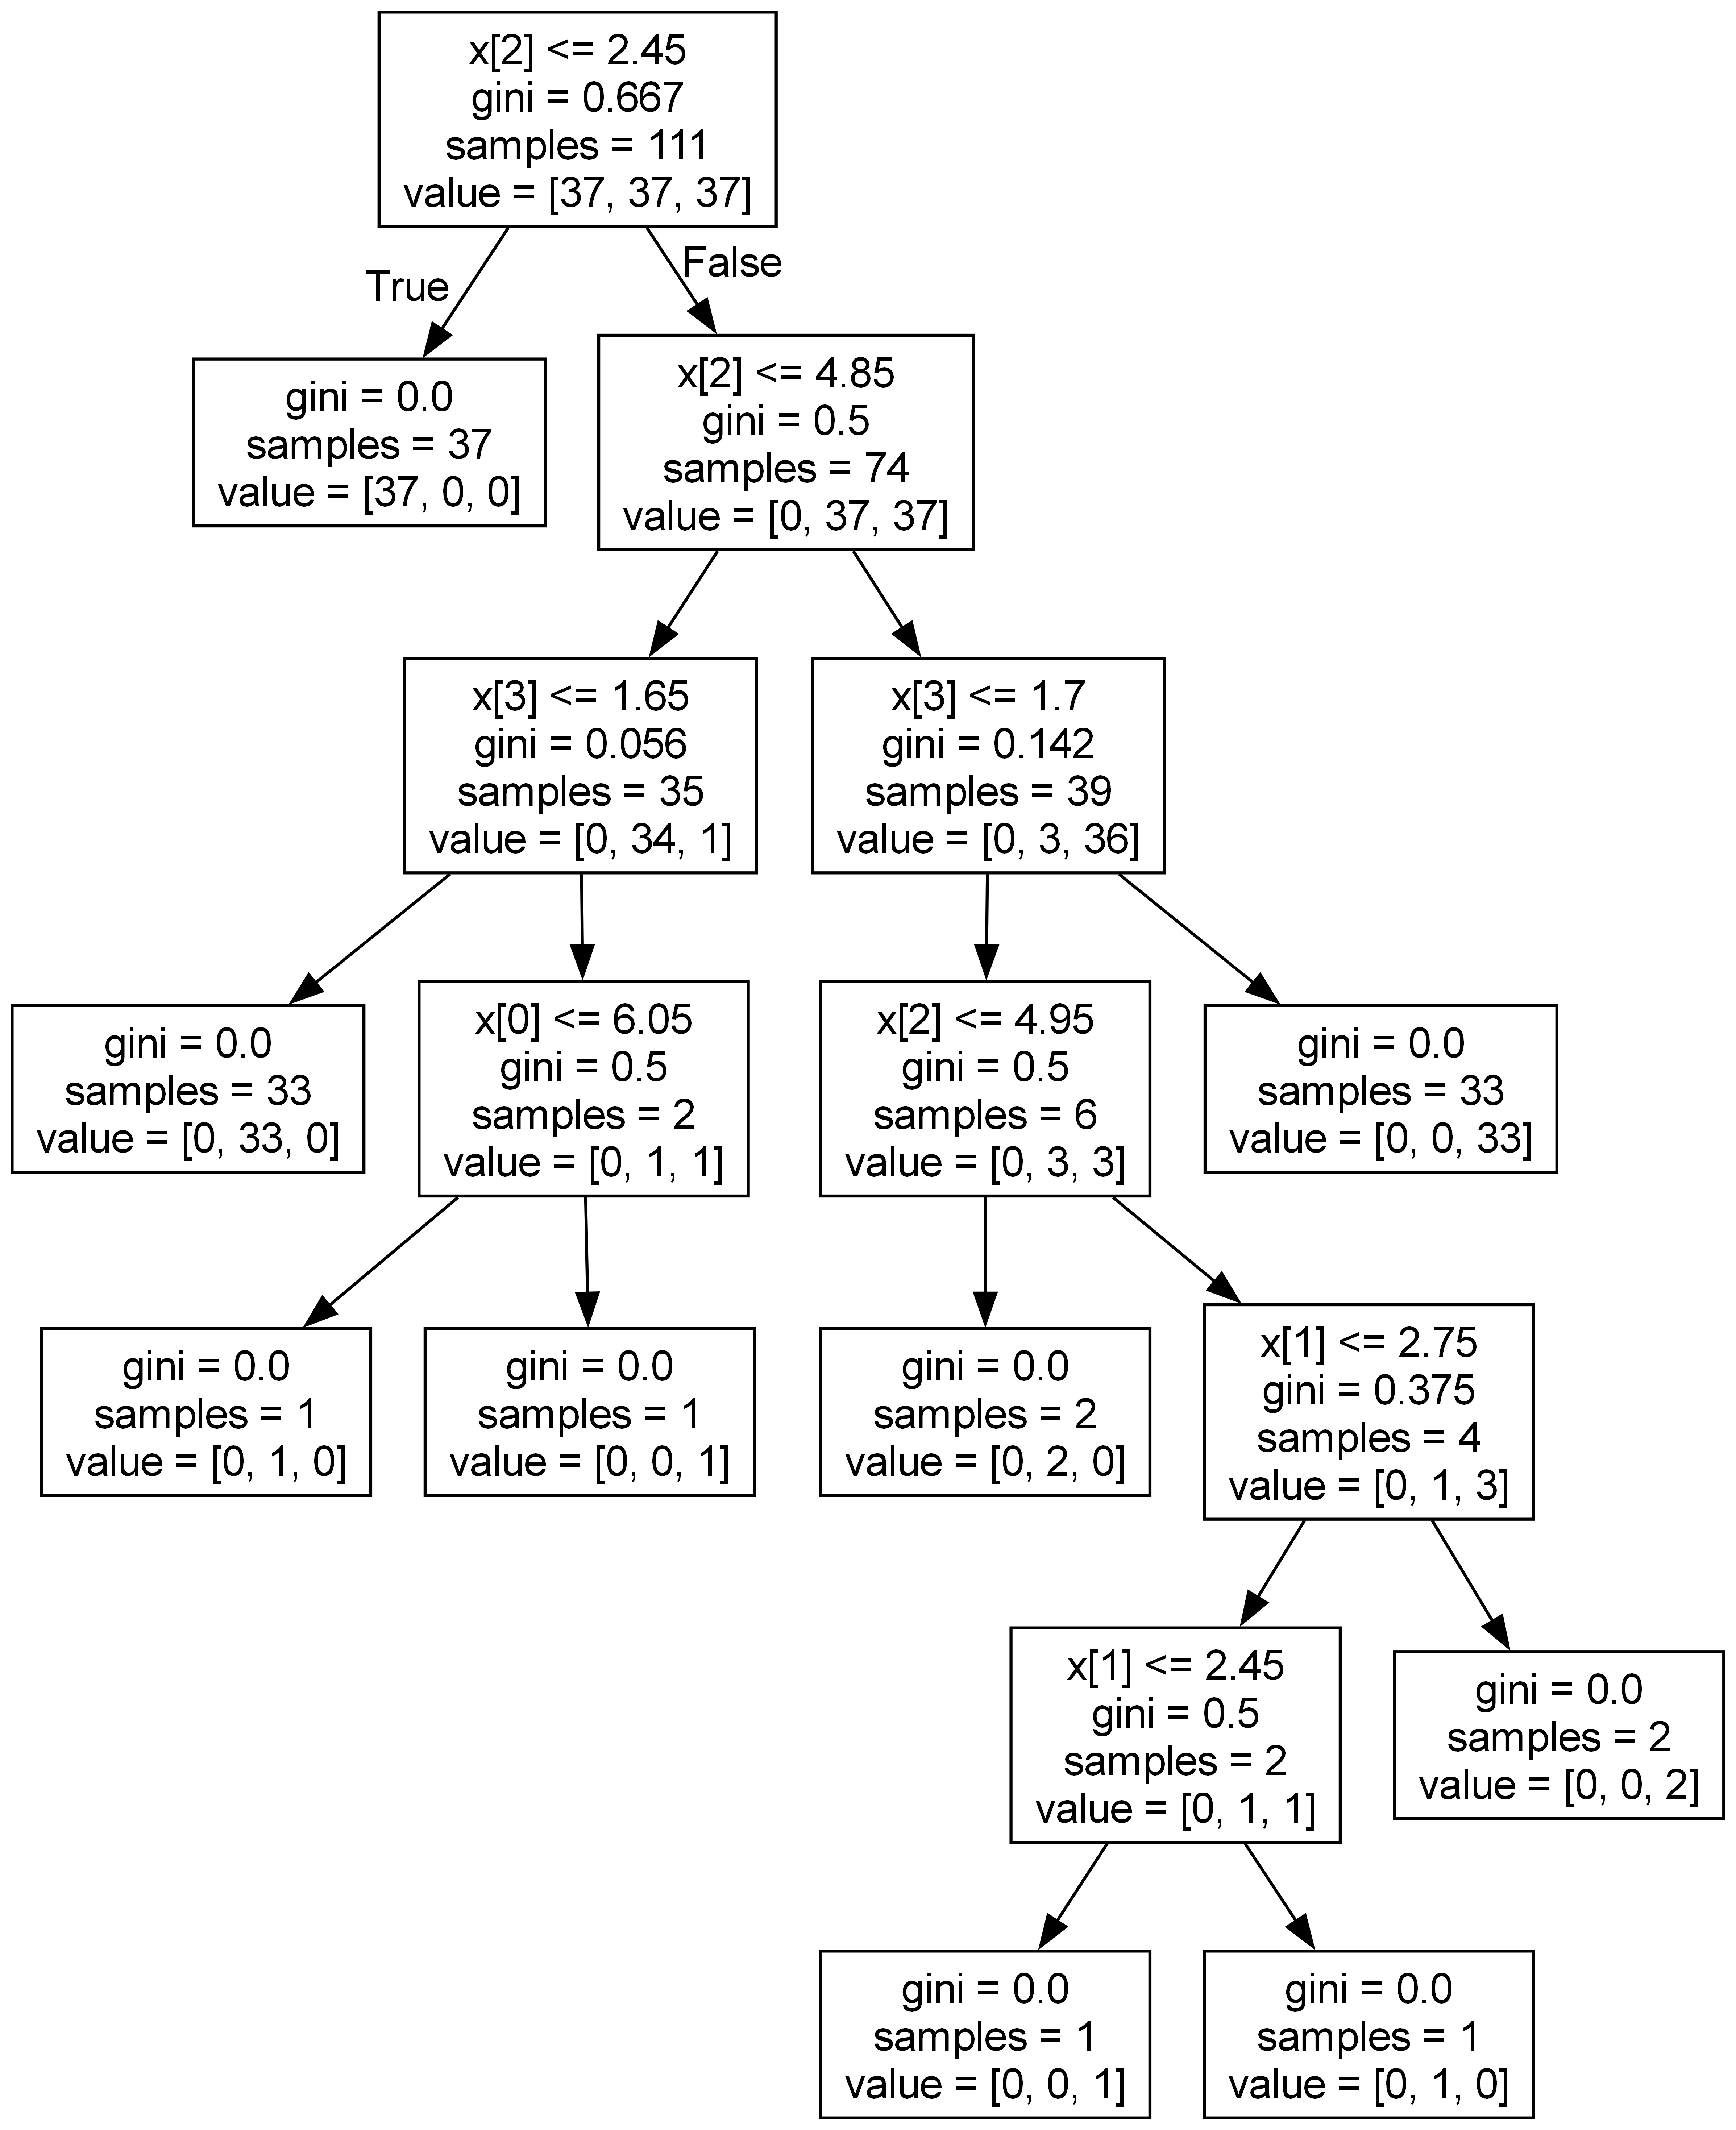

In [18]:
# 터미널 설치:
# pip install graphviz
# winget install Graphviz

# 💡 윈도우 환경 변수에 Graphviz 프로그램 엔진(dot.exe)이 있는 폴더 경로를 강제로 주입합니다.
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

# 의사결정나무 모델을 dot 파일로 추출
export_graphviz(model, out_file='tree.dot')

# dot 파일을 .png로 변환
call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

# png 출력
Image(filename = 'tree.png')

In [19]:
'''
문3-3> 테스트셋을 사용하여 위에서 생성한 의사결정나무 모델의 정확도를 출력하시오.
'''
# 테스트용 데이터로 모델 평가
score = model.score(X_test, y_test)
print('테스트셋의 정확도:{:.2f}'.format(score))

테스트셋의 정확도:0.89


In [20]:
'''
문3-4> 위에서 생성한 의사결정나무 모델을 활용하여 다음의 값을 포함하고 있는 꽃(new)은 어떤 품종으로 예측되는지 출력하시오.
'''
import numpy as np

new = np.array([[5.4, 4, 1.5, 0.2]])

y_pred = model.predict(new)
print('예측결과:{}'.format(y_pred))

예측결과:[0]


e:\wi\git\big0611\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
